# Final Assignment Set B — Classification track (Breast Cancer)

## Machine Learning Lab, Summer Semester 2026, Uni Passau

*Split from `final-assignment/SetB.ipynb`: this notebook keeps only the **classification** track (Breast Cancer — LogisticRegression baseline + SVM). See `concrete_strength_regression.ipynb` for the Concrete regression track.*

### Rules:

   1. Submissions must be pushed to your fimgit in a folder dubbed `final-assignment`.
   2. Run your solutions in cells under the individual Tasks.
   3. For model implementations you are permitted to use *only* your library in its final state before the commencement of the exam.

Goodluck!

---


### Task 1: Prepare your data

   1. Download the two datasets and read them into memory.

   2. Analyse the data shape, targets and data characteristics.

   3. Apply any data cleaning, filling mechanisms if required

   4. Split the datasets into `train`, `valid` and `test` folds.

Dataset 1: [CLASSIFICATION] Breast Cancer: https://archive.ics.uci.edu/dataset/14/breast+cancer

Dataset 2: [REGRESSION] Concrete Compressive Strength: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength


> Note: You may obtain the data any way you like from its UCI page

#### Imports & environment setup


In [1]:
# ---- Task 1: Imports & environment setup ----
# Data handling / plotting / preprocessing libraries. The MODELS (Tasks 2 & 4) come exclusively from our
# own `mlab` library, as required by the rules; scikit-learn is used ONLY for scaling/preprocessing.
import sys, subprocess, importlib

def _ensure(pkg, module=None):
    """Import `module` (defaults to `pkg`); pip-install `pkg` first if missing.
    Keeps the notebook self-contained/reproducible for the grader on any kernel."""
    try:
        return importlib.import_module(module or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        return importlib.import_module(module or pkg)

_ensure("ucimlrepo")
_ensure("matplotlib")
_ensure("scikit-learn", "sklearn")
_ensure("imbalanced-learn", "imblearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold

print("Imports ready:  numpy", np.__version__, "| pandas", pd.__version__)


Imports ready:  numpy 2.4.4 | pandas 3.0.2


#### Confusion-matrix plot helper

*One reusable helper used at every confusion-matrix site, so every confusion matrix is shown as a diagram. Returns `(tn, fp, fn, tp)`.*


In [2]:
# ---- Reusable confusion-matrix plot (matplotlib) ----
def plot_confusion(y_true, y_pred, title="Confusion matrix", labels=("no-recur", "recur"), ax=None):
    """Plot a 2x2 confusion matrix (rows=true, cols=predicted) and return (tn, fp, fn, tp)."""
    yt, yp = np.asarray(y_true).astype(int), np.asarray(y_pred).astype(int)
    cm = np.array([[int(((yt == 0) & (yp == 0)).sum()), int(((yt == 0) & (yp == 1)).sum())],
                   [int(((yt == 1) & (yp == 0)).sum()), int(((yt == 1) & (yp == 1)).sum())]])
    if ax is None:
        _, ax = plt.subplots(figsize=(3.4, 3.0))
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=8, rotation=15)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    tn, fp, fn, tp = cm.ravel()
    return int(tn), int(fp), int(fn), int(tp)

print("plot_confusion ready")

plot_confusion ready


#### Load the Breast Cancer dataset

*Downloads the Breast Cancer dataset from UCI and reads its features and target into memory.*

In [3]:
# ---- Task 1.1  Breast Cancer [CLASSIFICATION]: download & read into memory ----
# UCI id 14 (Ljubljana). Data loading via ucimlrepo is allowed by the rules.
breast_cancer = fetch_ucirepo(id=14)
bc_X = breast_cancer.data.features
bc_y = breast_cancer.data.targets
bc_target = bc_y.columns[0]

print("Breast Cancer (classification)")
print("  features:", bc_X.shape, "| targets:", bc_y.shape)
print("  columns :", list(bc_X.columns))
display(bc_X.head())
display(bc_y.head())


Breast Cancer (classification)
  features: (286, 9) | targets: (286, 1)
  columns : ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiat']


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no


,Class
0,no-recurrence-events
1,no-recurrence-events
2,no-recurrence-events
3,no-recurrence-events
4,no-recurrence-events


#### Explore & audit the Breast Cancer data

*Explores the data — shape, feature types, missing values, class balance, per-feature recurrence signal — with summary plots.*

In [4]:
# ---- Task 1.2  Breast Cancer: analysis & visualization ----
n, d = bc_X.shape
bc_num = bc_X.select_dtypes(include="number").columns.tolist()
bc_cat = bc_X.select_dtypes(exclude="number").columns.tolist()
print(f"Samples: {n}  |  Features: {d}")
print(f"Numeric features     ({len(bc_num)}): {bc_num}")
print(f"Categorical features ({len(bc_cat)}): {bc_cat}")
miss = bc_X.isna().sum(); miss = miss[miss > 0]
print("Missing values :", miss.to_dict() if len(miss) else "none")
print("Duplicate rows :", int(bc_X.duplicated().sum()))

counts = bc_y[bc_target].value_counts()
print("\nTarget class distribution:")
for cls, c in counts.items():
    print(f"  {cls:<22} {c:>4}  ({c / len(bc_y):.1%})")
print(f"  imbalance ratio (majority/minority): {counts.max() / counts.min():.2f} : 1")

Samples: 286  |  Features: 9
Numeric features     (1): ['deg-malig']
Categorical features (8): ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'breast', 'breast-quad', 'irradiat']
Missing values : {'node-caps': 8, 'breast-quad': 1}
Duplicate rows : 20

Target class distribution:
  no-recurrence-events    201  (70.3%)
  recurrence-events        85  (29.7%)
  imbalance ratio (majority/minority): 2.36 : 1


In [5]:
# --- Data-quality audit: Excel date-corrupted range labels ---
# Excel misread ranges like "5-9" as a date -> stored "9-May".
# Decode pattern: "{day}-{Mon}" was originally "{month_number}-{day}".
DECODE = {"9-May": "5-9",  "14-Oct": "10-14",                             # tumor-size
          "5-Mar": "3-5",  "8-Jun": "6-8", "11-Sep": "9-11", "14-Dec": "12-14"}  # inv-nodes
corrupted = {c: sorted(set(bc_X[c].dropna()) & set(DECODE)) for c in bc_cat}
corrupted = {c: v for c, v in corrupted.items() if v}
print("\n[data-quality] Excel-corrupted labels (to be fixed in the cleaning step):")
for c, v in corrupted.items():
    print(f"  {c:12s}: " + ", ".join(f"'{x}'->'{DECODE[x]}'" for x in v))


[data-quality] Excel-corrupted labels (to be fixed in the cleaning step):
  tumor-size  : '14-Oct'->'10-14', '9-May'->'5-9'
  inv-nodes   : '11-Sep'->'9-11', '14-Dec'->'12-14', '5-Mar'->'3-5', '8-Jun'->'6-8'


In [6]:
# --- Predictive signal: recurrence-rate spread per categorical feature ---
rec = bc_y[bc_target].eq("recurrence-events")
spread = pd.Series({c: (rec.groupby(bc_X[c]).mean().max() - rec.groupby(bc_X[c]).mean().min())
                    for c in bc_cat}).sort_values(ascending=False)
print("\nRecurrence-rate spread per feature (higher = stronger signal):")
display(spread.round(2).to_frame("rate_spread"))

print("Rare categories (count < 10) -> fragile for one-hot / stratified split:")
for c in bc_cat:
    vc = bc_X[c].value_counts(); rare = vc[vc < 10]
    if len(rare):
        print(f"  {c:12s}: {rare.to_dict()}")

# helper: order an ordinal range-feature by its (decoded) lower bound
def _order_ranges(series):
    cats = sorted(series.dropna().unique(),
                  key=lambda v: int(DECODE.get(v, v).split("-")[0]))
    return cats, [DECODE.get(v, v) for v in cats]



Recurrence-rate spread per feature (higher = stronger signal):


,rate_spread
inv-nodes,0.78
age,0.42
tumor-size,0.42
node-caps,0.32
irradiat,0.21
breast-quad,0.20
breast,0.05
menopause,0.05


Rare categories (count < 10) -> fragile for one-hot / stratified split:
  age         : {'70-79': 6, '20-29': 1}
  menopause   : {'lt40': 7}
  tumor-size  : {'0-4': 8, '50-54': 8, '9-May': 4, '45-49': 3}
  inv-nodes   : {'15-17': 6, '14-Dec': 3, '24-26': 1}


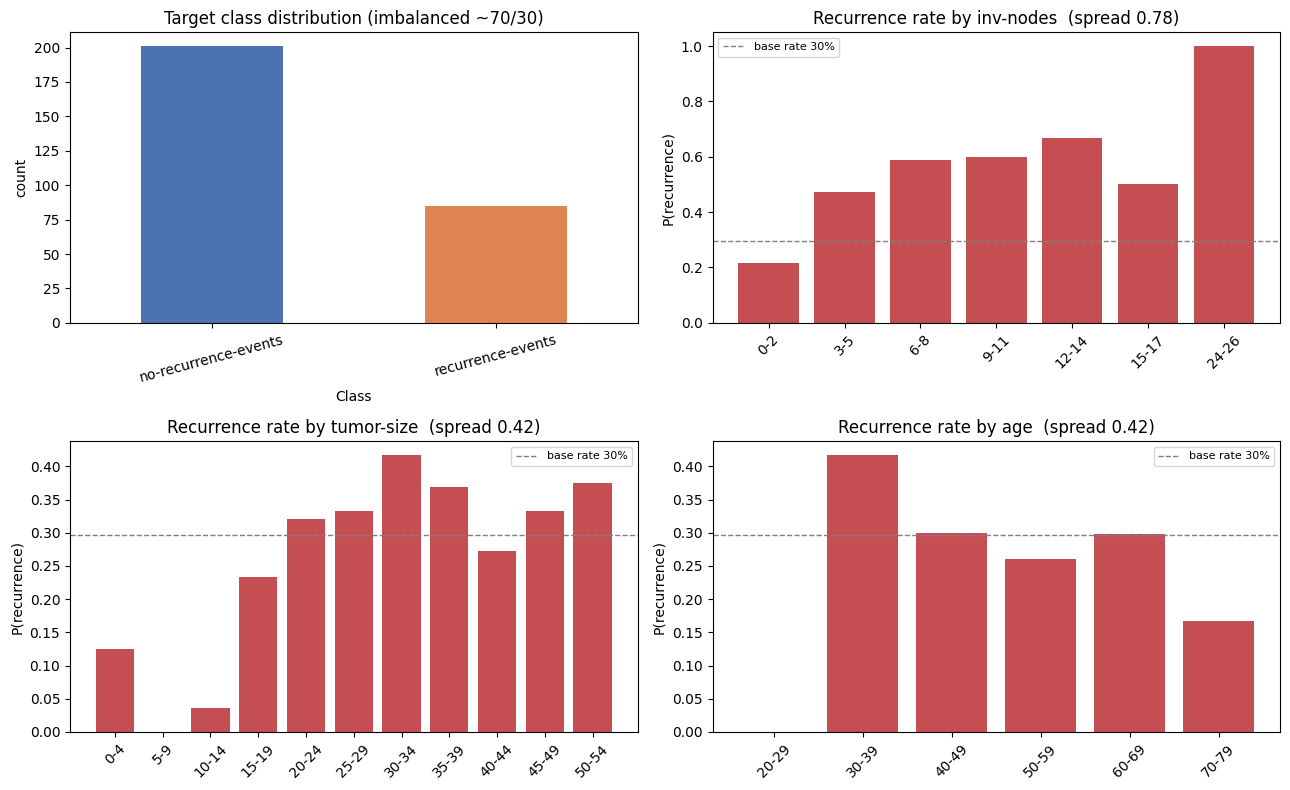

In [7]:

# ---------------- visualization ----------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
counts.plot(kind="bar", ax=axes[0, 0], color=["#4c72b0", "#dd8452"])
axes[0, 0].set_title("Target class distribution (imbalanced ~70/30)")
axes[0, 0].set_ylabel("count"); axes[0, 0].tick_params(axis="x", rotation=15)

base = rec.mean()
for ax, feat in zip([axes[0, 1], axes[1, 0], axes[1, 1]], ["inv-nodes", "tumor-size", "age"]):
    cats, disp = _order_ranges(bc_X[feat])
    r = rec.groupby(bc_X[feat]).mean().reindex(cats)
    ax.bar(disp, r.values, color="#c44e52")
    ax.axhline(base, ls="--", lw=1, color="gray", label=f"base rate {base:.0%}")
    ax.set_title(f"Recurrence rate by {feat}  (spread {spread[feat]:.2f})")
    ax.set_ylabel("P(recurrence)"); ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


#### Diagnose Breast Cancer data-quality issues

*Diagnoses data-quality issues (Excel-corrupted range labels, missing values, duplicates) and shows the evidence behind each cleaning decision.*

In [8]:
# ---- Task 1.3  Breast Cancer: cleaning rationale — show the issues, THEN clean ----
# Every cleaning action in the next cell is justified by the evidence printed here.

# (A) ISSUE — Excel date-corrupted range bins. Proof it's a fix, not a guess: each corrupted
#     label decodes to a bin that is otherwise MISSING, completing the ordinal grid.
DECODE = {"9-May": "5-9", "14-Oct": "10-14",                               # tumor-size (5-wide bins)
          "5-Mar": "3-5", "8-Jun": "6-8", "11-Sep": "9-11", "14-Dec": "12-14"}  # inv-nodes (3-wide bins)
for col, step in [("tumor-size", 5), ("inv-nodes", 3)]:
    order = lambda v: int(DECODE.get(v, v).split("-")[0])
    raw = sorted(bc_X[col].dropna().unique(), key=order)
    corrupt = [v for v in raw if v in DECODE]
    print(f"{col}: {len(corrupt)} corrupted -> {[f'{v}->{DECODE[v]}' for v in corrupt]}")
    print(f"   before decode: {raw}")
    print(f"   after  decode: {[DECODE.get(v, v) for v in raw]}   (fills the missing {step}-wide bins)\n")

# (B) ISSUE — missing values. Every feature here is CATEGORICAL, so numeric interpolation/mean
#     imputation does not apply (there is no ordered numeric axis to interpolate along) -> the correct
#     imputation is MODE-fill; the missing fraction is also tiny, so it is safe either way.
miss = bc_X.isna().sum(); miss = miss[miss > 0]
print(f"missing values: {miss.to_dict()}  = {miss.sum()}/{bc_X.size} cells ({miss.sum()/bc_X.size:.2%})")
print("   -> impute by MODE (features are categorical; interpolation / mean is undefined for them)\n")

# (C) ISSUE — duplicates. Classify them to decide keep vs drop.
full_b = pd.concat([bc_X, bc_y], axis=1)
conflict = int(full_b.groupby(list(bc_X.columns))[bc_target].nunique().gt(1).sum())
print(f"duplicates: feature-only={int(bc_X.duplicated().sum())}  "
      f"full-row(X+y)={int(full_b.duplicated().sum())}  conflicting-label profiles={conflict}")
print("-> DECISION: KEEP. Identical categorical profiles are legitimate distinct patients; "
      "conflicting labels are real (irreducible) noise, not data-entry errors.")


tumor-size: 2 corrupted -> ['9-May->5-9', '14-Oct->10-14']
   before decode: ['0-4', '9-May', '14-Oct', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54']
   after  decode: ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54']   (fills the missing 5-wide bins)

inv-nodes: 4 corrupted -> ['5-Mar->3-5', '8-Jun->6-8', '11-Sep->9-11', '14-Dec->12-14']
   before decode: ['0-2', '5-Mar', '8-Jun', '11-Sep', '14-Dec', '15-17', '24-26']
   after  decode: ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '24-26']   (fills the missing 3-wide bins)

missing values: {'node-caps': 8, 'breast-quad': 1}  = 9/2574 cells (0.35%)
   -> impute by MODE (features are categorical; interpolation / mean is undefined for them)

duplicates: feature-only=20  full-row(X+y)=14  conflicting-label profiles=6
-> DECISION: KEEP. Identical categorical profiles are legitimate distinct patients; conflicting labels are real (irreducible) noise, not data-entry err

#### Apply the Breast Cancer cleaning

*Applies the cleaning: fixes the corrupted labels, mode-imputes missing values, keeps duplicates, and encodes the target to 0/1.*

In [9]:
# ---- Task 1.3  Breast Cancer: apply cleaning (based on the diagnosis above) ----
bc_X_clean = bc_X.copy()

# (1) Fix the Excel date-corrupted range labels (proven in the diagnosis cell).
DECODE = {"9-May": "5-9", "14-Oct": "10-14",                               # tumor-size
          "5-Mar": "3-5", "8-Jun": "6-8", "11-Sep": "9-11", "14-Dec": "12-14"}  # inv-nodes
for col in ["tumor-size", "inv-nodes"]:
    bc_X_clean[col] = bc_X_clean[col].replace(DECODE)

# (2) Impute missing values with the column MODE (node-caps: 8, breast-quad: 1). Features are
#     categorical, so numeric interpolation/mean does not apply; mode is the standard choice.
for col in ["node-caps", "breast-quad"]:
    n_missing = int(bc_X_clean[col].isna().sum())
    mode = bc_X_clean[col].mode(dropna=True)[0]
    bc_X_clean[col] = bc_X_clean[col].fillna(mode)
    print(f"filled {n_missing:>2} missing in '{col}' with mode '{mode}'")

# (3) Duplicates: KEEP (see diagnosis: legitimate profiles + real label noise).
print(f"duplicate rows kept (categorical prevalence): {int(bc_X_clean.duplicated().sum())}")

# (4) Encode target -> 0/1, minority (clinically-relevant) class as positive.
bc_y_clean = bc_y[bc_target].map({"no-recurrence-events": 0, "recurrence-events": 1}).astype(int)

# ---- verify ----
assert bc_X_clean.isna().sum().sum() == 0, "missing values remain"
_left = {c: sorted(set(bc_X_clean[c]) & set(DECODE)) for c in ["tumor-size", "inv-nodes"]}
assert not any(_left.values()), f"corrupted labels remain: {_left}"
print(f"\nBreast Cancer cleaned:  X={bc_X_clean.shape}  y={bc_y_clean.shape}  "
      f"| positives={int(bc_y_clean.sum())} ({bc_y_clean.mean():.1%})")
display(bc_X_clean.head())


filled  8 missing in 'node-caps' with mode 'no'
filled  1 missing in 'breast-quad' with mode 'left_low'
duplicate rows kept (categorical prevalence): 20

Breast Cancer cleaned:  X=(286, 9)  y=(286,)  | positives=85 (29.7%)


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no


#### Encode features (ordinal + one-hot)

*Encodes features for modelling — ordinal codes for ordered ranges, one-hot for nominal — plus two engineered clinical features.*

In [10]:
# ---- Task 1.4  Breast Cancer: feature encoding (leak-free: fixed maps applied before the split) ----
# Ordered (ordinal) range features -> integer codes by their true order.
# Nominal features -> one-hot. deg-malig is already an ordinal integer (1..3), left as-is.
ordinal_cols = ["age", "tumor-size", "inv-nodes"]
nominal_cols = ["menopause", "node-caps", "breast", "breast-quad", "irradiat"]

def ordinal_encode(s):
    order = sorted(s.unique(), key=lambda v: int(str(v).split("-")[0]))
    return s.map({v: i for i, v in enumerate(order)}), order

bc_X_enc = bc_X_clean.copy()
for col in ordinal_cols:
    bc_X_enc[col], order = ordinal_encode(bc_X_enc[col])
    print(f"ordinal '{col:10s}': {order}  -> 0..{len(order) - 1}")

# ---- Clinically-motivated engineered features (added BEFORE the split -> leak-free) ----
# inv-nodes is by far the strongest signal (recurrence-rate spread 0.78 vs next 0.42), but a linear model
# can only read its monotone ordinal code. We add (a) "node_positive" = ANY positive axillary node (a hard
# clinical threshold), and (b) a deg-malig x inv-nodes interaction (high grade AND node-heavy = synergistic
# high-risk group). These give the models non-linear structure they could not otherwise express.
bc_X_enc["node_positive"] = (bc_X_enc["inv-nodes"] >= 1).astype(int)
bc_X_enc["degmalig_x_invnodes"] = bc_X_enc["deg-malig"] * bc_X_enc["inv-nodes"]
print("engineered: node_positive (inv-nodes>=1), degmalig_x_invnodes (deg-malig x inv-nodes)")

# Nominal -> one-hot with drop_first=True: drop each feature's redundant reference level, removing the
# exact collinearity of the previous drop_first=False encoding (cleaner L2 solution, lower variance).
bc_X_enc = pd.get_dummies(bc_X_enc, columns=nominal_cols, drop_first=True).astype(float)
print(f"\nencoded matrix: {bc_X_clean.shape} -> {bc_X_enc.shape}  ({bc_X_enc.shape[1]} numeric features)")
print("columns:", list(bc_X_enc.columns))
display(bc_X_enc.head())

ordinal 'age       ': ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']  -> 0..5
ordinal 'tumor-size': ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54']  -> 0..10
ordinal 'inv-nodes ': ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '24-26']  -> 0..6
engineered: node_positive (inv-nodes>=1), degmalig_x_invnodes (deg-malig x inv-nodes)

encoded matrix: (286, 9) -> (286, 15)  (15 numeric features)
columns: ['age', 'tumor-size', 'inv-nodes', 'deg-malig', 'node_positive', 'degmalig_x_invnodes', 'menopause_lt40', 'menopause_premeno', 'node-caps_yes', 'breast_right', 'breast-quad_left_low', 'breast-quad_left_up', 'breast-quad_right_low', 'breast-quad_right_up', 'irradiat_yes']


,age,tumor-size,inv-nodes,deg-malig,node_positive,degmalig_x_invnodes,menopause_lt40,menopause_premeno,node-caps_yes,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,irradiat_yes
0,1.0,6.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2.0,4.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2.0,4.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


#### Held-out test split + stratified 10-fold CV

*Splits off a stratified 20% held-out test set and builds the stratified 10-fold cross-validation folds on the rest.*

In [11]:
# ---- Task 1.4  Breast Cancer: held-out test + 10-fold stratified CV (scikit-learn splitters) ----
def make_folds(y, k=10, stratify=False, seed=42):
    """List of (train_idx, val_idx) positional index pairs into the dev arrays (sklearn KFold splitters)."""
    splitter = (StratifiedKFold(n_splits=k, shuffle=True, random_state=seed) if stratify
                else KFold(n_splits=k, shuffle=True, random_state=seed))
    return list(splitter.split(np.zeros(len(y)), np.asarray(y)))

SEED, K = 42, 10
bc_Xdev, bc_Xte, bc_ydev, bc_yte = train_test_split(
    bc_X_enc, bc_y_clean, test_size=0.20, random_state=SEED, shuffle=True, stratify=bc_y_clean)
bc_folds = make_folds(bc_ydev, k=K, stratify=True, seed=SEED)

print(f"Breast Cancer:  dev={bc_Xdev.shape}  test={bc_Xte.shape}   ({K}-fold stratified CV on dev)")
print(f"  test positives: {int(np.asarray(bc_yte).sum())}/{len(bc_yte)} ({np.asarray(bc_yte).mean():.1%})")
fold_pos = [float(np.asarray(bc_ydev)[val].mean()) for _, val in bc_folds]
print(f"  per-fold val positive-rate: {min(fold_pos):.2f}..{max(fold_pos):.2f} (stratified) | val fold size ~{len(bc_folds[0][1])}")


Breast Cancer:  dev=(228, 15)  test=(58, 15)   (10-fold stratified CV on dev)
  test positives: 17/58 (29.3%)
  per-fold val positive-rate: 0.27..0.30 (stratified) | val fold size ~23


### Class imbalance handling

The recurrence class is the minority (~30%), so imbalance is handled explicitly. Below illustrates **SMOTE** oversampling on the dev set. In the models: the logistic baseline uses mlab's built-in balanced class weights; the offset-free RBF SVM rebalances each training fold by oversampling (Tasks 4–6). Rebalancing is always **in-fold / leak-free** — the held-out test keeps its true ratio.


In [12]:
# ---- Data-level rebalancing helpers (imbalanced-learn; sklearn-compatible, preprocessing only) ----
# imblearn provides the standard resamplers; the MODELS still come only from mlab. Interface:
# reb_fn(X, y, seed) -> (X_bal, y_bal). Applied only to a TRAINING fold, never to validation/test.
from imblearn.over_sampling import RandomOverSampler, SMOTE

def _to_arr(X):
    return X.values if hasattr(X, "values") else np.asarray(X)

def oversample_minority(X, y, seed=42):
    """Random oversampling of the minority class to 50/50 (imblearn RandomOverSampler). Used by the SVM."""
    Xr, yr = RandomOverSampler(random_state=seed).fit_resample(_to_arr(X), np.asarray(y))
    return np.asarray(Xr), np.asarray(yr)

def smote_oversample(X, y, k=5, seed=42):
    """SMOTE synthetic oversampling of the minority class (imblearn SMOTE); used for the balanced-data view.
    NOTE: one-hot/binary columns become fractional after interpolation."""
    Xa, ya = _to_arr(X), np.asarray(y)
    n_min = int(np.bincount(ya.astype(int)).min())
    Xr, yr = SMOTE(random_state=seed, k_neighbors=min(k, max(n_min - 1, 1))).fit_resample(Xa, ya)
    return np.asarray(Xr), np.asarray(yr)

print("Rebalancing helpers ready (imbalanced-learn): oversample_minority, smote_oversample")

Rebalancing helpers ready (imbalanced-learn): oversample_minority, smote_oversample


#### Class balance — before vs after SMOTE

*Shows SMOTE's effect on the class distribution (illustrative — applied to the whole dev set just to visualise). Models rebalance in-fold; the held-out test is never balanced.*


In [13]:
# ---- Class balance: cleaned (imbalanced) dev set  vs  SMOTE-balanced dev set (illustrative only) ----
Xdev_raw, ydev_raw = bc_Xdev.values, np.asarray(bc_ydev)
Xdev_bal, ydev_bal = smote_oversample(Xdev_raw, ydev_raw, seed=SEED)   # SMOTE, applied for illustration

def _dist(y):
    u, c = np.unique(np.asarray(y), return_counts=True)
    return {int(k): int(v) for k, v in zip(u, c)}
d_before, d_after = _dist(ydev_raw), _dist(ydev_bal)

print("Class balance - before vs after SMOTE (dev set; illustrative):\n")
print(f"  {'':28s} {'no-recur(0)':>11s} {'recur(1)':>9s} {'total':>7s} {'maj:min':>8s}")
for label, d in [("after cleaning (imbalanced)", d_before), ("after balancing (SMOTE)", d_after)]:
    maj, mino = d.get(0, 0), d.get(1, 0)
    print(f"  {label:28s} {maj:>11d} {mino:>9d} {maj + mino:>7d} {maj / max(mino, 1):>6.2f}:1")

print(f"\n  dev X: {Xdev_raw.shape} -> {Xdev_bal.shape}   (+{len(ydev_bal) - len(ydev_raw)} synthetic minority rows)")
print(f"  held-out test stays imbalanced (honest eval): "
      f"{int((np.asarray(bc_yte) == 1).sum())}/{len(bc_yte)} positives ({np.asarray(bc_yte).mean():.1%})")

Class balance - before vs after SMOTE (dev set; illustrative):

                               no-recur(0)  recur(1)   total  maj:min
  after cleaning (imbalanced)          160        68     228   2.35:1
  after balancing (SMOTE)              160       160     320   1.00:1

  dev X: (228, 15) -> (320, 15)   (+92 synthetic minority rows)
  held-out test stays imbalanced (honest eval): 17/58 positives (29.3%)


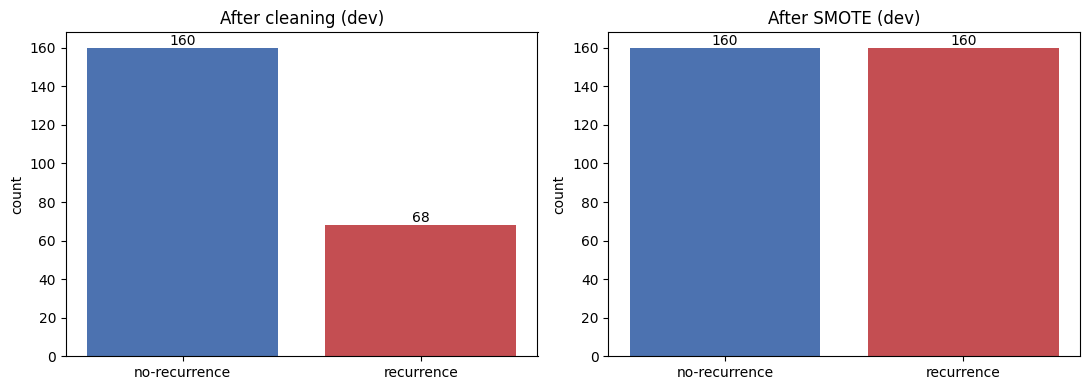

In [14]:
# ---- plot: class balance before vs after ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (title, d) in zip(ax, [("After cleaning (dev)", d_before), ("After SMOTE (dev)", d_after)]):
    vals = [d.get(0, 0), d.get(1, 0)]
    a.bar(["no-recurrence", "recurrence"], vals, color=["#4c72b0", "#c44e52"])
    a.set_title(title); a.set_ylabel("count")
    for i, v in enumerate(vals):
        a.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

### Task 2: Implement baseline model of your choice (1 classification + 1 regression) for each of the two datasets. Please note you cannot use models required in Task 4 as baselines.

```python
baseline = YourAlgorithm()
baseline.learn(features_train, labels_train)
```

#### Load the baseline model & metrics from `mlab`

*Loads the logistic-regression baseline and its classification metrics from the `mlab` library (the regression baseline and the SVM are loaded in their own cells).*


In [15]:
# ---- Task 2: load the baseline model & metrics from the mlab library ----
# Each library folder defines its own top-level `mlab`, so we load the needed files by path.
import sys, importlib.util, pathlib

def _find_libs():
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        for cand in (base / "libraries" / "mlab", base / "final-assignment" / "libraries" / "mlab",
                     base / "libraries", base / "final-assignment" / "libraries"):
            if (cand / "MLRegKit").exists() and (cand / "logitlab").exists():
                return cand
    raise FileNotFoundError("Could not locate final-assignment/libraries/")
LIBS = _find_libs()

def _load_mlab(name, relpath):
    spec = importlib.util.spec_from_file_location(name, LIBS / relpath)
    mod = importlib.util.module_from_spec(spec); sys.modules[name] = mod
    spec.loader.exec_module(mod); return mod

_logistic_mod = _load_mlab("mlab_logistic", "logitlab/mlab/regression/_logistic.py")

LogisticRegression = _logistic_mod.LogisticRegression   # full-batch GD; balanced weights + L2
# StandardScaler is imported from scikit-learn above (preprocessing is allowed; only MODELS must be mlab).
clf = _logistic_mod                                     # precision_score / recall_score / f1_score / confusion_matrix


#### Leak-free k-fold cross-validation helper

*Defines the leak-free k-fold cross-validation helper (the scaler is fit inside each fold).*

In [16]:
def cv_report(Xdev, ydev, folds, make_model, metrics, scale=True, report_train=False):
    """k-fold CV. If scale=True, fit a StandardScaler INSIDE each fold (leak-free) before the model;
    use scale=False for models that standardize internally (SVM / ANN). Returns {metric: (mean, std)}.
    With report_train=True, also returns 'train_<metric>' keys (scored on the TRAIN fold) so the
    train-vs-validation gap can be inspected as an overfitting check."""
    Xv = Xdev.values if hasattr(Xdev, "values") else np.asarray(Xdev)
    yv = np.asarray(ydev)
    acc    = {m: [] for m in metrics}
    acc_tr = {m: [] for m in metrics}
    for tr, val in folds:
        if scale:
            sc = StandardScaler().fit(Xv[tr]); Xtr, Xval = sc.transform(Xv[tr]), sc.transform(Xv[val])
        else:
            Xtr, Xval = Xv[tr], Xv[val]
        model = make_model().fit(Xtr, yv[tr])
        pred = np.asarray(model.predict(Xval)).ravel()
        for m, fn in metrics.items():
            acc[m].append(fn(yv[val], pred))
        if report_train:
            pred_tr = np.asarray(model.predict(Xtr)).ravel()
            for m, fn in metrics.items():
                acc_tr[m].append(fn(yv[tr], pred_tr))
    out = {m: (float(np.mean(v)), float(np.std(v))) for m, v in acc.items()}
    if report_train:
        out.update({f"train_{m}": (float(np.mean(v)), float(np.std(v))) for m, v in acc_tr.items()})
    return out

print("Loaded mlab baselines + metrics + CV helper from:", LIBS)


Loaded mlab baselines + metrics + CV helper from: /home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab


#### Classification metrics

*Defines the classification metric set (accuracy, precision, recall, F1) used throughout.*

In [17]:
# ---- Task 2  Breast Cancer baseline: LogisticRegression — 10-fold CV on the dev set ----
# Balanced class weights + L2 are built in. Scaler is fit inside each fold (leak-free).
# report_train=True also scores the TRAIN folds so we can read the train-vs-validation gap.
acc_fn = lambda yt, yp: float(np.mean(np.asarray(yt) == np.asarray(yp)))
bc_metrics = {"accuracy": acc_fn, "precision": clf.precision_score,
              "recall": clf.recall_score, "f1": clf.f1_score}


#### Baseline logistic — 10-fold CV (train-vs-validation gap)

*Runs 10-fold cross-validation of the logistic baseline and reports the train-vs-validation gap as an overfitting check.*

In [18]:
_bc_cv_all = cv_report(bc_Xdev, bc_ydev, bc_folds,
                       lambda: LogisticRegression(learning_rate=0.1, n_iterations=1000),
                       bc_metrics, report_train=True)
# bc_cv stays validation-only (4 keys) — that is what the rest of the notebook consumes.
bc_cv       = {m: _bc_cv_all[m]            for m in bc_metrics}
bc_cv_train = {m: _bc_cv_all[f"train_{m}"] for m in bc_metrics}

print("Breast Cancer — LogisticRegression (balanced)  |  10-fold CV on dev:")
print(f"  {'metric':9s} {'train':>13s} {'val':>13s} {'gap':>7s}")
for m in bc_metrics:
    tr_mu, tr_sd = bc_cv_train[m]
    va_mu, va_sd = bc_cv[m]
    print(f"  {m:9s} {tr_mu:.3f} ± {tr_sd:.3f} {va_mu:.3f} ± {va_sd:.3f} {tr_mu - va_mu:+.3f}")
print("  (gap = train − val; small gap → not overfitting)")

Breast Cancer — LogisticRegression (balanced)  |  10-fold CV on dev:
  metric            train           val     gap
  accuracy  0.720 ± 0.016 0.636 ± 0.112 +0.083
  precision 0.522 ± 0.019 0.419 ± 0.132 +0.104
  recall    0.722 ± 0.032 0.576 ± 0.233 +0.146
  f1        0.606 ± 0.019 0.477 ± 0.163 +0.129
  (gap = train − val; small gap → not overfitting)


#### Logistic baseline — confusion matrix & CV metrics plot

*Plots a pooled **out-of-fold** confusion matrix (leak-free, from the 10 CV folds) and the train-vs-validation CV metrics for the logistic baseline.*


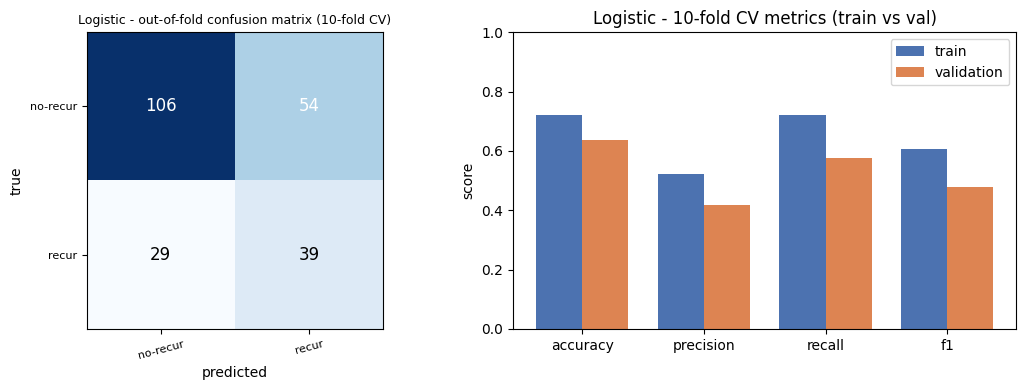

Out-of-fold confusion matrix (n=228):  TN=106  FP=54  FN=29  TP=39
  recall(recurrence)=0.574  precision=0.419  specificity=0.662


In [19]:
# ---- Logistic baseline: out-of-fold (CV) confusion matrix + train-vs-val metrics plot ----
# Pool leak-free out-of-fold predictions across the 10 folds -> one representative confusion matrix.
_Xv, _yv = bc_Xdev.values, np.asarray(bc_ydev)
_oof_pred = np.zeros(len(_yv), dtype=int)
for tr, val in bc_folds:
    sc = StandardScaler().fit(_Xv[tr])
    m = LogisticRegression(learning_rate=0.1, n_iterations=1000).fit(sc.transform(_Xv[tr]), _yv[tr])
    _oof_pred[val] = np.asarray(m.predict(sc.transform(_Xv[val]))).ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# (1) out-of-fold confusion matrix (shared helper)
tn, fp, fn, tp = plot_confusion(_yv, _oof_pred, "Logistic - out-of-fold confusion matrix (10-fold CV)", ax=ax[0])
# (2) train vs validation CV metrics
mets = list(bc_metrics)
tr_v = [bc_cv_train[m][0] for m in mets]; va_v = [bc_cv[m][0] for m in mets]
x = np.arange(len(mets)); w = 0.38
ax[1].bar(x - w / 2, tr_v, w, label="train", color="#4c72b0")
ax[1].bar(x + w / 2, va_v, w, label="validation", color="#dd8452")
ax[1].set_xticks(x); ax[1].set_xticklabels(mets); ax[1].set_ylim(0, 1)
ax[1].set_title("Logistic - 10-fold CV metrics (train vs val)"); ax[1].set_ylabel("score"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Out-of-fold confusion matrix (n={len(_yv)}):  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  recall(recurrence)={tp/(tp+fn):.3f}  precision={tp/(tp+fp):.3f}  specificity={tn/(tn+fp):.3f}")

#### Baseline logistic — fit final model on the full dev set

*Fits the final logistic baseline on the full development set for the held-out test evaluation.*

In [20]:
# fit the FINAL model on the full dev set (used for the held-out test evaluation in Task 3)
bc_scaler   = StandardScaler().fit(bc_Xdev.values)
bc_baseline = LogisticRegression(learning_rate=0.1, n_iterations=1000).fit(
    bc_scaler.transform(bc_Xdev.values), np.asarray(bc_ydev))

### Task 3: Evaluate your baseline models on test set: 
Use accuracy, precision and recall for classification, and R2 score and MAE/RMSE for regression
```python
baseline_predicted = model_baseline.infer(features_test)
evaluate_fn(baseline_predicted, labels_test)
```

#### Evaluate the baseline logistic on the held-out test set

*Evaluates the logistic baseline on the held-out test set (accuracy, precision, recall, F1, confusion matrix).*

Breast Cancer — LogisticRegression baseline  (TEST, n=58)   [test vs 10-fold CV]
  accuracy : 0.672   (CV 0.636 ± 0.112)
  precision: 0.458   (CV 0.419 ± 0.132)
  recall   : 0.647   (CV 0.576 ± 0.233)
  f1-score : 0.537   (CV 0.477 ± 0.163)
  confusion matrix:  TN=28  FP=13  FN=6  TP=11
  per-class accuracy:  recurrence(event)=0.647  |  no-recurrence=0.683
  balanced accuracy :  0.665


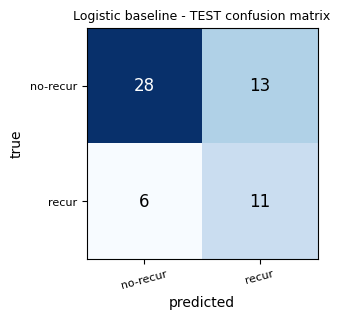

In [21]:
# ---- Task 3  Breast Cancer: evaluate the final baseline on the held-out TEST set ----
yte = np.asarray(bc_yte)
bc_pred = bc_baseline.predict(bc_scaler.transform(bc_Xte.values))
acc  = float(np.mean(bc_pred == yte))
prec = clf.precision_score(yte, bc_pred)
rec  = clf.recall_score(yte, bc_pred)
f1   = clf.f1_score(yte, bc_pred)
tn, fp, fn, tp = clf.confusion_matrix(yte, bc_pred).ravel()

print(f"Breast Cancer — LogisticRegression baseline  (TEST, n={len(yte)})   [test vs 10-fold CV]")
print(f"  accuracy : {acc:.3f}   (CV {bc_cv['accuracy'][0]:.3f} ± {bc_cv['accuracy'][1]:.3f})")
print(f"  precision: {prec:.3f}   (CV {bc_cv['precision'][0]:.3f} ± {bc_cv['precision'][1]:.3f})")
print(f"  recall   : {rec:.3f}   (CV {bc_cv['recall'][0]:.3f} ± {bc_cv['recall'][1]:.3f})")
print(f"  f1-score : {f1:.3f}   (CV {bc_cv['f1'][0]:.3f} ± {bc_cv['f1'][1]:.3f})")
print(f"  confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
acc_pos = tp / (tp + fn) if (tp + fn) else 0.0   # accuracy on the recurrence (event) class (= recall/sensitivity)
acc_neg = tn / (tn + fp) if (tn + fp) else 0.0   # accuracy on the no-recurrence class (= specificity)
print(f"  per-class accuracy:  recurrence(event)={acc_pos:.3f}  |  no-recurrence={acc_neg:.3f}")
print(f"  balanced accuracy :  {0.5 * (acc_pos + acc_neg):.3f}")

plot_confusion(yte, bc_pred, "Logistic baseline - TEST confusion matrix"); plt.show()


### Task 4: Implement and train the following methods:

    a) SVM with any non-linear kernel for classification 
    b) ANN for regression
    
- Use one fixed train-validation-test split consistently for all experiments
- Report the same metrics used for the baselines on the test set.

#### SVM helpers (balanced-accuracy scorer + rebalancer)

*The two helpers the SVM needs: balanced accuracy (grid-search selection metric under imbalance) and the in-fold rebalancer.*


In [22]:
# ---- SVM helpers (used in Tasks 4-5) ----
def bal_acc(y_true, y_pred):
    """Balanced accuracy = mean(recall_pos, recall_neg); the SVM grid-search selection metric."""
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    pos, neg = yt == 1, yt == 0
    tpr = float(np.mean(yp[pos] == 1)) if pos.any() else 0.0
    tnr = float(np.mean(yp[neg] == 0)) if neg.any() else 0.0
    return 0.5 * (tpr + tnr)

# The offset-free kernel SVM rebalances each train fold by RANDOM OVERSAMPLING (exact 50/50 duplication):
# it re-centres the boundary (the naive SVM otherwise collapses to the majority class).
svm_reb_fn = oversample_minority

print("SVM helpers ready: bal_acc, svm_reb_fn (=random oversampling)")

SVM helpers ready: bal_acc, svm_reb_fn (=random oversampling)


#### Load the SVM model from `mlab`

*Loads the SVM (RBF-kernel classifier) from the `mlab` library.*

In [23]:
# ---- Task 4: load the SVM (classification, RBF kernel) from mlab ----

# svm-lib uses relative imports, so import it as a proper package. Its `mlab` is the only one on
# sys.path (the baselines were loaded by file), so there is no namespace clash.
_svm_root = str(LIBS / "svm-lib")
if _svm_root not in sys.path:
    sys.path.insert(0, _svm_root)
from mlab.svm import SVC

print("Task-4 model loaded:", SVC.__name__, "(SVM, RBF kernel)")


Task-4 model loaded: SVC (SVM, RBF kernel)


#### SVM (RBF) — 10-fold CV on the dev set

*Runs 10-fold cross-validation of the RBF-kernel SVM on the development set.*

In [24]:
# ---- Task 4a  Breast Cancer: SVM with RBF (non-linear) kernel — 10-fold CV + held-out test ----
# SVC standardizes internally, so we pass RAW features (scale=False -> no double-scaling).
svm_cv = cv_report(bc_Xdev, bc_ydev, bc_folds,
                   lambda: SVC(kernel="rbf", C=1.0, gamma=None, random_state=SEED),
                   bc_metrics, scale=False)
print("Breast Cancer — SVM (RBF kernel)  |  10-fold CV on dev:")
for m, (mu, sd) in svm_cv.items():
    print(f"  {m:9s}: {mu:.3f} ± {sd:.3f}   (baseline CV {bc_cv[m][0]:.3f})")


Breast Cancer — SVM (RBF kernel)  |  10-fold CV on dev:
  accuracy : 0.698 ± 0.054   (baseline CV 0.636)
  precision: 0.521 ± 0.291   (baseline CV 0.419)
  recall   : 0.224 ± 0.122   (baseline CV 0.576)
  f1       : 0.292 ± 0.136   (baseline CV 0.477)


#### SVM (RBF) — fit final model & evaluate on the held-out test

*Fits the final SVM and evaluates it on the held-out test, exposing its majority-class collapse.*


Breast Cancer — SVM (RBF)  (TEST, n=58):
  accuracy : 0.724   (baseline 0.672)
  precision: 0.571   (baseline 0.458)
  recall   : 0.235   (baseline 0.647)
  f1-score : 0.333   (baseline 0.537)
  confusion matrix:  TN=38  FP=3  FN=13  TP=4
  per-class accuracy:  recurrence(event)=0.235  |  no-recurrence=0.927
  balanced accuracy :  0.581


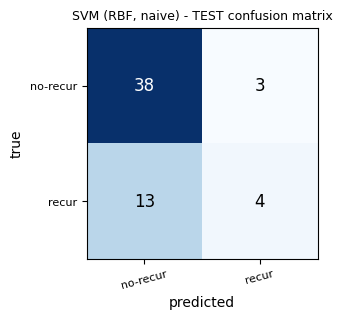

In [25]:
# final model on full dev -> held-out test
bc_svm = SVC(kernel="rbf", C=1.0, gamma=None, random_state=SEED).fit(bc_Xdev.values, np.asarray(bc_ydev))
svm_pred = np.asarray(bc_svm.predict(bc_Xte.values)).ravel()
tn, fp, fn, tp = clf.confusion_matrix(yte, svm_pred).ravel()
print(f"\nBreast Cancer — SVM (RBF)  (TEST, n={len(yte)}):")
print(f"  accuracy : {np.mean(svm_pred == yte):.3f}   (baseline {acc:.3f})")
print(f"  precision: {clf.precision_score(yte, svm_pred):.3f}   (baseline {prec:.3f})")
print(f"  recall   : {clf.recall_score(yte, svm_pred):.3f}   (baseline {rec:.3f})")
print(f"  f1-score : {clf.f1_score(yte, svm_pred):.3f}   (baseline {f1:.3f})")
print(f"  confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
acc_pos = tp / (tp + fn) if (tp + fn) else 0.0   # accuracy on the recurrence (event) class (= recall/sensitivity)
acc_neg = tn / (tn + fp) if (tn + fp) else 0.0   # accuracy on the no-recurrence class (= specificity)
print(f"  per-class accuracy:  recurrence(event)={acc_pos:.3f}  |  no-recurrence={acc_neg:.3f}")
print(f"  balanced accuracy :  {0.5 * (acc_pos + acc_neg):.3f}")

plot_confusion(yte, svm_pred, "SVM (RBF, naive) - TEST confusion matrix"); plt.show()


### Task 5: Hyperparameter Optimisation
- For each of the models implemented in Task 4, conduct a grid search in reasonable ranges to find an appropriate set of hyperparameters, and justify the choice.

```python
possible_hp_values = np.arange(1, 10, 0.1)
best_hp_value = None
best_f1_score = -np.infty
for hp_value in possible_hp_values:
    # 1. create a baseline classifier object with hp_value specified
    current_model = YourAlgorithm(hyperparam=hp_value)
    
    # 2. learn the classifier on the training set
    current_model.learn(features_train, labels_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.infer(features_valid)
    
    f1_score = compute_f1(labels_valid, prediction)
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_hp_value = hp_value

print("Found hyperparameter value", best_hp_value)
print("Best f1-score on validation set", best_f1_score)

test_model = YourAlgorithm(hyperparam=best_hp_value)
test_model.learn(features_train, labels_train)
prediction = test_model.infer(features_test)
test_f1_score = compute_f1(labels_test, prediction)
print("F1-Score on test set", test_f1_score)
```

#### SVM grid search — the balanced-CV scorer

*Defines the balanced-accuracy CV scorer that oversamples inside each fold for the SVM grid search.*

In [26]:
# ---- Task 5a  Breast Cancer SVM: 10-fold CV grid search over (C, gamma), rebalanced + balanced-acc ----
# The naive SVM collapsed to the majority class. Root cause: the mlab kernel path learns no bias term, so
# on imbalanced data the (offset-free) boundary sits in the majority region. We therefore (1) OVERSAMPLE
# each TRAIN fold to 50/50 (random oversampling -- best for this offset-free kernel) -- and (2) SELECT
# by CV BALANCED ACCURACY (raw accuracy would reward the majority-only predictor). Rebalancing is done
# INSIDE each fold (leak-free); the validation fold keeps the true class ratio.
import itertools

def cv_svm_balanced(Xdev, ydev, folds, C, gamma, metrics):
    Xv = Xdev.values if hasattr(Xdev, "values") else np.asarray(Xdev); yv = np.asarray(ydev)
    scores = {m: [] for m in metrics}
    for tr, val in folds:
        Xb, yb = svm_reb_fn(Xv[tr], yv[tr], seed=SEED)
        m = SVC(kernel="rbf", C=C, gamma=gamma, random_state=SEED).fit(Xb, yb)
        pred = np.asarray(m.predict(Xv[val])).ravel()
        for name, fn in metrics.items():
            scores[name].append(fn(yv[val], pred))
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in scores.items()}


#### SVM grid search over (C, gamma), ranked by CV balanced-accuracy

*Runs the (C, gamma) grid search ranked by CV balanced-accuracy to pick the SVM hyperparameters.*

In [27]:
svm_sel_metrics = {"bal_acc": bal_acc, "f1": clf.f1_score, "recall": clf.recall_score, "accuracy": acc_fn}
svm_grid = {"C": [50, 100, 200, 500, 1000], "gamma": [0.01, 0.02, 0.03, 0.05, 0.08]}
svm_results = [({"C": C, "gamma": g}, cv_svm_balanced(bc_Xdev, bc_ydev, bc_folds, C, g, svm_sel_metrics))
               for C, g in itertools.product(svm_grid["C"], svm_grid["gamma"])]
svm_results.sort(key=lambda r: -r[1]["bal_acc"][0])
svm_best, svm_best_cv = svm_results[0]

print(f"SVM grid: {len(svm_results)} combos x {K}-fold CV (oversampled folds), ranked by CV balanced-accuracy (top 5):")
for params, cvres in svm_results[:5]:
    print(f"  C={params['C']:<5} gamma={params['gamma']:<5} -> bal_acc={cvres['bal_acc'][0]:.3f}  "
          f"F1={cvres['f1'][0]:.3f}  recall={cvres['recall'][0]:.3f}  acc={cvres['accuracy'][0]:.3f}")
print(f"\nChosen SVM: {svm_best}   (CV balanced-acc {svm_best_cv['bal_acc'][0]:.3f} +/- {svm_best_cv['bal_acc'][1]:.3f}, "
      f"CV F1 {svm_best_cv['f1'][0]:.3f})   [naive C=1 SVM CV F1 was {svm_cv['f1'][0]:.3f}]")

/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


...

/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


SVM grid: 25 combos x 10-fold CV (oversampled folds), ranked by CV balanced-accuracy (top 5):
  C=50    gamma=0.03  -> bal_acc=0.597  F1=0.413  recall=0.426  acc=0.667
  C=100   gamma=0.05  -> bal_acc=0.593  F1=0.420  recall=0.455  acc=0.649
  C=500   gamma=0.08  -> bal_acc=0.588  F1=0.418  recall=0.457  acc=0.641
  C=500   gamma=0.05  -> bal_acc=0.580  F1=0.423  recall=0.486  acc=0.619
  C=200   gamma=0.02  -> bal_acc=0.580  F1=0.379  recall=0.398  acc=0.654

Chosen SVM: {'C': 50, 'gamma': 0.03}   (CV balanced-acc 0.597 +/- 0.081, CV F1 0.413)   [naive C=1 SVM CV F1 was 0.292]


/home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab/svm-lib/mlab/svm/_svm.py:405: ConvergenceWarning: Kernel SVM did not converge after 1000 epochs. Consider increasing max_iter.
  warnings.warn(


#### Handling class imbalance — SVM (kernel-bias workaround)

The mlab kernel `SVC` learns **no bias term** (`bias_=0`) and has **no `class_weight`**, so the naive SVM collapses to the majority class. We fix this at the data level, leak-free: **oversample each training fold to 50/50** (re-centres the offset-free boundary), **select `(C, γ)` by CV balanced-accuracy**, and place the test operating point with a **prior-matched threshold** (a quantile of the model's own scores — scale-invariant).


In [28]:
# ---- Task 5a  Breast Cancer SVM: final rebalanced model + held-out operating point ----
# Fit the chosen (C, gamma) on the FULL oversampled dev set; the test stays imbalanced (honest evaluation).
Xdev_over, ydev_over = svm_reb_fn(bc_Xdev, bc_ydev, seed=SEED)
bc_svm_final = SVC(kernel="rbf", random_state=SEED, **svm_best).fit(Xdev_over, ydev_over)
svm_dec_te = np.asarray(bc_svm_final.decision_function(bc_Xte.values)).ravel()

#### Prior-matched decision threshold (for the SVM)

*Defines the prior-matched threshold — a scale-invariant decision cut-off for the SVM's uncalibrated scores.*

In [29]:
# Prior-matched decision threshold: a quantile of each model's OWN score distribution, so it is
# scale-invariant and transfers even for the SVM's uncalibrated, bias-free margins. Targets a
# predicted-positive rate equal to the class prevalence. Uses reference features only (no label leak).
def prior_matched_threshold(model, X_ref, prevalence, score_fn):
    s = np.asarray(score_fn(model, X_ref)).ravel()
    return float(np.quantile(s, 1.0 - prevalence))

print("Helper ready: prior_matched_threshold")

Helper ready: prior_matched_threshold


#### SVM (final) — prior-matched operating point & test summary

*Sets the SVM's prior-matched operating point and summarises the test results at each threshold.*

SVM (RBF, C=50, gamma=0.03, oversampled)
  CV balanced-acc 0.597 +/- 0.081  |  CV F1 0.413   <- primary estimate (10-fold CV)

  TEST operating points (n=58, prior-matched threshold -0.82):
  default C=1 (collapsed)      recall=0.235  prec=0.571  F1=0.333  bal_acc=0.581  TP=4/17
  rebalanced @natural(0)       recall=0.529  prec=0.474  F1=0.500  bal_acc=0.643  TP=9/17
  rebalanced @prior-matched    recall=0.588  prec=0.370  F1=0.455  bal_acc=0.587  TP=10/17


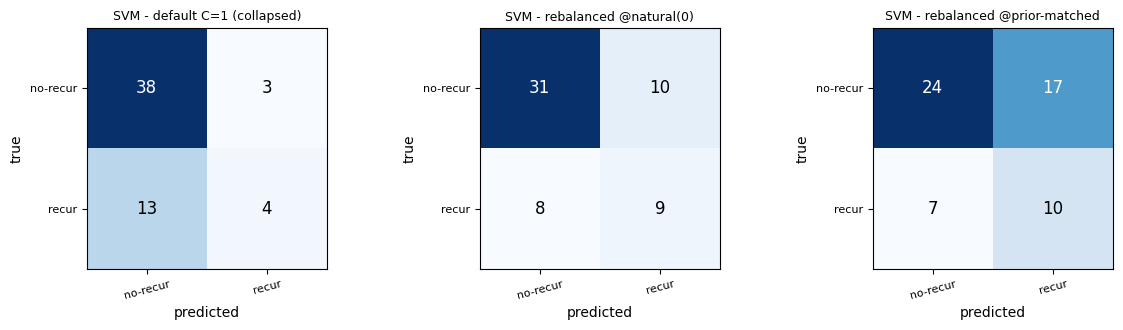


  NOTE: the single n=58 test is a noisy draw; the 10-fold CV and the 20-run stability test
  are the honest estimates. The operating point uses a prior-matched threshold because the kernel
  SVM's offset-free margins are uncalibrated (mlab's SVC has no bias term).


In [30]:
# Operating point: PRIOR-MATCHED threshold (scale-invariant -> transfers despite the uncalibrated,
# bias-free margins). Targets predicted-positive rate = dev prevalence.
PREV = float(np.asarray(bc_ydev).mean())
tau_svm = prior_matched_threshold(bc_svm_final, bc_Xdev.values, PREV, lambda m, X: m.decision_function(X))

print(f"SVM (RBF, C={svm_best['C']}, gamma={svm_best['gamma']}, oversampled)")
print(f"  CV balanced-acc {svm_best_cv['bal_acc'][0]:.3f} +/- {svm_best_cv['bal_acc'][1]:.3f}  |  "
      f"CV F1 {svm_best_cv['f1'][0]:.3f}   <- primary estimate (10-fold CV)")
print(f"\n  TEST operating points (n={len(yte)}, prior-matched threshold {tau_svm:.2f}):")
_ops = [
    ("default C=1 (collapsed)", np.asarray(SVC(kernel='rbf', C=1.0, random_state=SEED)
        .fit(bc_Xdev.values, np.asarray(bc_ydev)).predict(bc_Xte.values)).ravel()),
    ("rebalanced @natural(0)", (svm_dec_te >= 0).astype(int)),
    ("rebalanced @prior-matched", (svm_dec_te >= tau_svm).astype(int)),
]
_fig, _axes = plt.subplots(1, 3, figsize=(12, 3.4))
for (_name, _pred), _ax in zip(_ops, _axes):
    _tn, _fp, _fn, _tp = plot_confusion(yte, _pred, f"SVM - {_name}", ax=_ax)
    print(f"  {_name:<28s} recall={clf.recall_score(yte, _pred):.3f}  prec={clf.precision_score(yte, _pred):.3f}  "
          f"F1={clf.f1_score(yte, _pred):.3f}  bal_acc={bal_acc(yte, _pred):.3f}  TP={_tp}/{int(yte.sum())}")
plt.tight_layout(); plt.show()
print(f"\n  NOTE: the single n={len(yte)} test is a noisy draw; the 10-fold CV and the 20-run stability test")
print(f"  are the honest estimates. The operating point uses a prior-matched threshold because the kernel")
print(f"  SVM's offset-free margins are uncalibrated (mlab's SVC has no bias term).")

### Task 6: Statistical/stability tests

- over multiple runs $r \geq 5, r\in\mathbb{N}$  randomly shuffle your training data
- split it into a train-test, e.g. 90% of the data is for training, 10% for testing
- Report the mean and standard deviation of the error/accuracy of your models over the multiple runs
- plot a boxplot of the stability of your model

#### Stability test — the resampling harness (20 × 90/10)

*Defines the stability harness: repeatedly reshuffle, take a 90/10 split, fit, and score.*

In [31]:
# ---- Task 6  Breast Cancer: stability over R shuffled 90/10 train-test runs ----
# Compares the BASELINE logistic (mlab balanced weights, default 0.5 threshold) against the required SVM.
# The SVM oversamples its TRAIN split and uses a PRIOR-MATCHED cut (its uncalibrated, bias-free margins mean
# an absolute threshold would not transfer) -- necessary for the kernel SVM, not a baseline tweak.
# This 20-run mean +/- std is the honest primary estimate; the single held-out test is one noisy draw.
RUNS = 20
def stability_runs(X, y, model_from, metric_fns, scale, runs=RUNS, test_frac=0.10, seed0=100,
                   stratify=False, predict_fn=None):
    """Re-shuffle -> 90/10 split -> fit -> score, `runs` times. Returns {metric: [per-run scores]}.
    predict_fn(Xtr, ytr, Xte, seed) overrides the default fit/predict (threshold tuning / oversampling)."""
    Xv = X.values if hasattr(X, "values") else np.asarray(X); yv = np.asarray(y); n = len(yv)
    out = {m: [] for m in metric_fns}
    for r in range(runs):
        rng = np.random.default_rng(seed0 + r)
        if stratify:
            te_parts = []
            for c in np.unique(yv):
                ci = np.where(yv == c)[0]; rng.shuffle(ci)
                te_parts.append(ci[:int(round(test_frac * len(ci)))])
            te = np.concatenate(te_parts); tr = np.setdiff1d(np.arange(n), te); rng.shuffle(tr)
        else:
            idx = rng.permutation(n); nte = int(round(test_frac * n)); te, tr = idx[:nte], idx[nte:]
        Xtr, Xte = Xv[tr], Xv[te]
        if scale:
            sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        if predict_fn is not None:
            pred = np.asarray(predict_fn(Xtr, yv[tr], Xte, seed0 + r)).ravel()
        else:
            pred = np.asarray(model_from().fit(Xtr, yv[tr]).predict(Xte)).ravel()
        for m, fn in metric_fns.items():
            out[m].append(fn(yv[te], pred))
    return out


#### Per-model predictors & per-class metrics

*Defines the per-model predictors (baseline logistic, rebalanced SVM) and per-class metrics for the stability runs.*


In [32]:
def log_baseline_predict(Xtr, ytr, Xte, seed):
    """Baseline logistic (mlab balanced weights, default 0.5 threshold); scaler fit on the TRAIN split."""
    sc = StandardScaler().fit(Xtr)
    mm = LogisticRegression(learning_rate=0.1, n_iterations=1000).fit(sc.transform(Xtr), ytr)
    return np.asarray(mm.predict(sc.transform(Xte))).ravel()

def svm_over_predict(Xtr, ytr, Xte, seed):
    """SVM rebalanced by random oversampling of the train split; prior-matched (scale-invariant) decision cut."""
    Xb, yb = svm_reb_fn(Xtr, ytr, seed=seed)
    m = SVC(kernel="rbf", random_state=SEED, **svm_best).fit(Xb, yb)
    t = prior_matched_threshold(m, Xtr, float(np.asarray(ytr).mean()), lambda mm, X: mm.decision_function(X))
    return (np.asarray(m.decision_function(Xte)).ravel() >= t).astype(int)

# per-class accuracy tracked across the runs (event = recurrence = class 1)
def _acc_pos(yt, yp):
    yt, yp = np.asarray(yt), np.asarray(yp); m = yt == 1
    return float(np.mean(yp[m] == 1)) if m.any() else 0.0
def _acc_neg(yt, yp):
    yt, yp = np.asarray(yt), np.asarray(yp); m = yt == 0
    return float(np.mean(yp[m] == 0)) if m.any() else 0.0
def _bal_acc(yt, yp):
    return 0.5 * (_acc_pos(yt, yp) + _acc_neg(yt, yp))

cls_metrics = {"accuracy": acc_fn, "f1": clf.f1_score, "f2": lambda yt, yp: (lambda p, r: 5*p*r/(4*p+r) if (4*p+r) else 0.0)(
                   clf.precision_score(yt, yp), clf.recall_score(yt, yp)),
               "acc_recurrence": _acc_pos, "acc_no_recurrence": _acc_neg, "balanced_acc": _bal_acc}


#### Run the stability test & report mean ± std

*Runs the 20-run stability test for both models and reports the mean ± std.*

In [33]:
bc_log_stab = stability_runs(bc_X_enc, bc_y_clean, None, cls_metrics, scale=False, stratify=True,
                             predict_fn=log_baseline_predict)
bc_svm_stab = stability_runs(bc_X_enc, bc_y_clean, None, cls_metrics, scale=False, stratify=True,
                             predict_fn=svm_over_predict)

print(f"Breast Cancer - stability over {RUNS} shuffled 90/10 runs (mean +/- std):")
print(f"  [LogReg = baseline (default 0.5 threshold) | SVM = oversampled, prior-matched cut]")
for name, st in [("LogReg (baseline)", bc_log_stab), ("SVM RBF (rebalanced)", bc_svm_stab)]:
    print(f"  {name:22s} F1 {np.mean(st['f1']):.3f} +/- {np.std(st['f1']):.3f}  |  "
          f"F2 {np.mean(st['f2']):.3f}  |  accuracy {np.mean(st['accuracy']):.3f} +/- {np.std(st['accuracy']):.3f}")
    print(f"  {'':22s} recurrence-recall {np.mean(st['acc_recurrence']):.3f} +/- {np.std(st['acc_recurrence']):.3f}"
          f"  |  no-recurrence {np.mean(st['acc_no_recurrence']):.3f}"
          f"  |  balanced {np.mean(st['balanced_acc']):.3f} +/- {np.std(st['balanced_acc']):.3f}")


Breast Cancer - stability over 20 shuffled 90/10 runs (mean +/- std):
  [LogReg = baseline (default 0.5 threshold) | SVM = oversampled, prior-matched cut]
  LogReg (baseline)      F1 0.475 +/- 0.155  |  F2 0.532  |  accuracy 0.648 +/- 0.084
                         recurrence-recall 0.581 +/- 0.225  |  no-recurrence 0.675  |  balanced 0.628 +/- 0.117
  SVM RBF (rebalanced)   F1 0.442 +/- 0.173  |  F2 0.441  |  accuracy 0.686 +/- 0.105
                         recurrence-recall 0.444 +/- 0.203  |  no-recurrence 0.782  |  balanced 0.613 +/- 0.126


#### Stability boxplots

*Plots boxplots of F1 and recurrence recall across the 20 runs.*

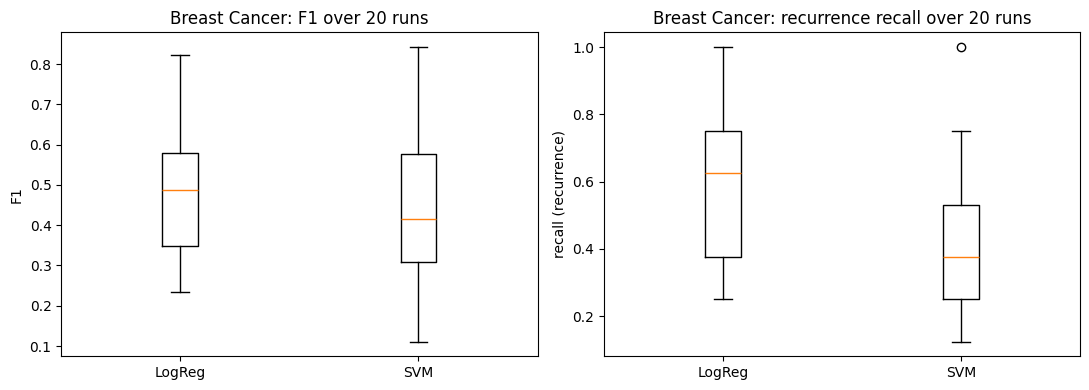

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([bc_log_stab['f1'], bc_svm_stab['f1']], tick_labels=['LogReg', 'SVM'])
ax[0].set_title(f"Breast Cancer: F1 over {RUNS} runs"); ax[0].set_ylabel("F1")
ax[1].boxplot([bc_log_stab['acc_recurrence'], bc_svm_stab['acc_recurrence']], tick_labels=['LogReg', 'SVM'])
ax[1].set_title(f"Breast Cancer: recurrence recall over {RUNS} runs"); ax[1].set_ylabel("recall (recurrence)")
plt.tight_layout(); plt.show()